# Q1: Supervised Learning - Heart Disease Prediction

In this task, we build classification models to predict whether a patient has heart disease. We perform data exploration, preprocessing, model training, and evaluation using multiple algorithms.

   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptomatic       114.0        177.0           0   
4   37    1      non_anginal       149.0        271.0           0   

                    resting_ecg  max_hr  exercise_angina  oldpeak st_slope  \
0  left_ventricular_hypertrophy     169                0      0.4       up   
1         st_t_wave_abnormality     121                1      1.1       up   
2                        normal     183                1      0.2       up   
3         st_t_wave_abnormality     150                0      1.0       up   
4                        normal     136                0      0.4     flat   

   heart_disease  
0              1  
1              1  
2              0  
3              1  
4              0  
<c

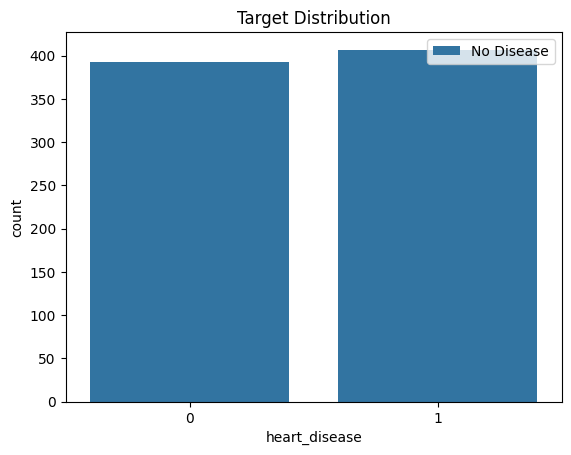

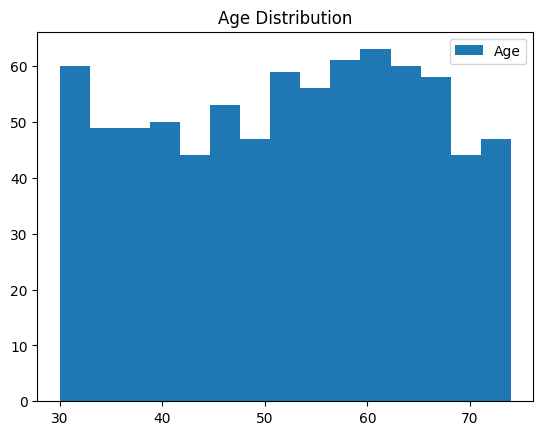

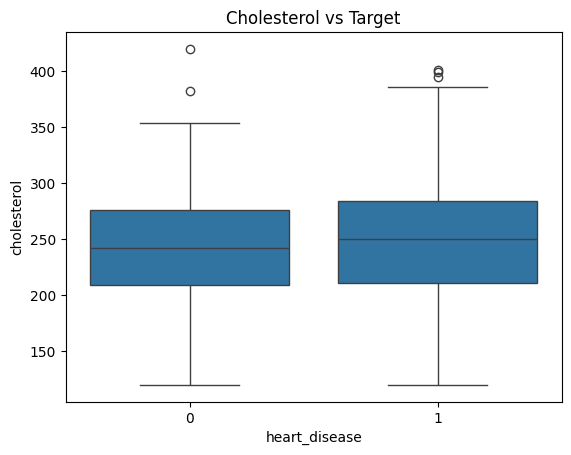


 Decision Tree
[[56 23]
 [25 56]]
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160


 Random Forest
[[61 18]
 [15 66]]
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


 Gradient Boosting
[[61 18]
 [19 62]]
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Load data
df = pd.read_csv('../data/q1_heart_disease.csv')

# Basic info
print(df.head())
print(df.info())
print(df.isnull().sum())

# EDA
plt.figure()
sns.countplot(x='heart_disease', data=df)
plt.title("Target Distribution")
plt.legend(["No Disease", "Disease"])
plt.show()

plt.figure()
plt.hist(df['age'], bins=15, label="Age")
plt.title("Age Distribution")
plt.legend()
plt.show()

plt.figure()
sns.boxplot(x='heart_disease', y='cholesterol', data=df)
plt.title("Cholesterol vs Target")
plt.show()

# Preprocessing
df.fillna(df.median(numeric_only=True), inplace=True)
df = pd.get_dummies(df, drop_first=True)

X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\n", name)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

## Conclusion

Among the models, ensemble methods like Random Forest and Gradient Boosting performed better compared to Decision Tree. These models captured patterns in the data more effectively, resulting in higher accuracy and balanced precision-recall scores.